In [1]:
# Verificar las carpetas necesarias dentro del proyecto actual
import os

carpetas = [
    "app",
    "datos",
    "evidencias",
    "docs",
    "logs",
    "dashboard"
]

for carpeta in carpetas:
    os.makedirs(carpeta, exist_ok=True)

print("Estructura necesaria verificada correctamente.")

Estructura necesaria verificada correctamente.


#Fase 1
## 1.1 Definición del problema

Desarrollar un modelo de machine learning capaz de predecir el tiempo estimado en días para desarrollar módulos de software, considerando diversas características del módulo como el número de interfaces de usuario, la cantidad de funcionalidades backend, el nivel de complejidad y las horas disponibles de trabajo por día.

En una empresa con un único desarrollador, el avance del proyecto depende directamente de su disponibilidad, ya que no es posible reducir el tiempo mediante trabajo en paralelo. Por esta razón, un modelo de regresión lineal resulta adecuado para estimar cómo el tiempo de desarrollo aumenta de manera proporcional conforme crece la cantidad y complejidad de las funcionalidades.

En conclusión, el modelo permite realizar estimaciones más objetivas del tiempo de desarrollo, facilitando la planificación de actividades y una mejor estimación de los tiempos de entrega.

Este modelo será desplegado posteriormente mediante una API desarrollada con FastAPI y empaquetado en un contenedor Docker, con el objetivo de validar su funcionamiento en un entorno local y documentar su posible despliegue en la nube.


In [2]:
# Importar librerías
import json
import os

from datetime import datetime, timezone

import joblib
import mlflow
import mlflow.sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [3]:
np.random.seed(42) # garantizar reproducibilidad

**Generación de datos sintéticos**

Debido a que no se dispone de un historial real de módulos desarrollados, se generó un conjunto de datos sintéticos compuesto por 1,000 módulos de software. Cada registro representa un módulo independiente y contiene características que influyen en su tiempo de desarrollo, como el número de interfaces de usuario, la cantidad de funcionalidades del backend, el nivel de complejidad y las horas disponibles de trabajo por día.

La variable objetivo se calculó mediante una función que simula la relación entre estas variables. Se agrega un pequeño ruido aleatorio para simular la variabilidad de proyectos reales.

Esfuerzo=*(Interfaces×5)+(Funcionalidades×4)+(Complejidad×12*

Cálculo de la duración
Duración (días) =* Esfuerzo (horas) / Horas disponibles por día *


In [4]:
# Generación de datos sintéticos

datos = []

for i in range(1, 1001):

    complejidad = np.random.randint(1, 6)


    if complejidad == 1:
        interfaces = np.random.randint(1, 4)
        funcionalidades = np.random.randint(2, 6)

    elif complejidad == 2:
        interfaces = np.random.randint(2, 6)
        funcionalidades = np.random.randint(4, 9)

    elif complejidad == 3:
        interfaces = np.random.randint(4, 9)
        funcionalidades = np.random.randint(8, 13)

    elif complejidad == 4:
        interfaces = np.random.randint(6, 11)
        funcionalidades = np.random.randint(12, 17)

    else:
        interfaces = np.random.randint(8, 16)
        funcionalidades = np.random.randint(16, 21)


    horas_dia = np.random.randint(4, 9)

    esfuerzo_horas = (
        interfaces * 5 +
        funcionalidades * 4 +
        complejidad * 12 +
        np.random.normal(0, 5)
    )

    esfuerzo_horas = max(esfuerzo_horas, 8)

    duracion_dias = esfuerzo_horas / horas_dia

    # Se agrega un poco de variación
    duracion_dias += np.random.normal(0, 0.5)

    # Evitar valores negativos
    duracion_dias = max(duracion_dias, 1)


    datos.append({
        "modulo": f"M{i:04}",
        "interfaces_usuario": interfaces,
        "funcionalidades_backend": funcionalidades,
        "complejidad": complejidad,
        "horas_disponibles_dia": horas_dia,
        "duracion_estimada_dias": round(duracion_dias, 2)
    })

# Crear DataFrame
data = pd.DataFrame(datos)

# Mostrar las primeras filas
data.head()

,modulo,interfaces_usuario,funcionalidades_backend,complejidad,horas_disponibles_dia,duracion_estimada_dias
0,M0001,10,14,4,8,19.57
1,M0002,6,12,3,7,16.10
2,M0003,9,19,5,5,35.50
3,M0004,7,16,4,7,20.80
4,M0005,5,7,2,7,9.43


In [5]:
# Guardar el conjunto de datos
data.to_csv("datos/dataset_sintetico.csv", index=False)

print("Dataset guardado correctamente.")

Dataset guardado correctamente.


In [6]:
# Configuración local de MLflow con SQLite
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("Estimador_Tiempo_Modulos")

TEST_SIZE = 0.20
RANDOM_STATE = 42

print("MLflow configurado correctamente.")
print("Tracking URI:", mlflow.get_tracking_uri())

MLflow configurado correctamente.
Tracking URI: sqlite:///mlflow.db


# Análisis Exploratorio de Datos Breve



1.   Verificar la estructura del dataset con data.info()
2.   Generar estadísticas descriptivas.
3.   Revisar la distribución de la complejidad (value_counts()).
4.   Visualizar la distribución de la duración estimada con un gráfico histograma.
5.   Analizar la correlación entre las variables mediante una matriz de correlación.

In [7]:
# info general del dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   modulo                   1000 non-null   object 
 1   interfaces_usuario       1000 non-null   int64  
 2   funcionalidades_backend  1000 non-null   int64  
 3   complejidad              1000 non-null   int64  
 4   horas_disponibles_dia    1000 non-null   int64  
 5   duracion_estimada_dias   1000 non-null   float64
dtypes: float64(1), int64(4), object(1)
memory usage: 47.0+ KB


In [8]:
# Estadísticas descriptivas
data.describe()

,interfaces_usuario,funcionalidades_backend,complejidad,horas_disponibles_dia,duracion_estimada_dias
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,6.306000,10.586000,3.063000,5.984000,19.584240
std,3.666034,5.438215,1.401069,1.408449,11.171657
min,1.000000,2.000000,1.000000,4.000000,2.170000
25%,3.000000,5.000000,2.000000,5.000000,9.700000
50%,6.000000,11.000000,3.000000,6.000000,18.325000
75%,9.000000,16.000000,4.000000,7.000000,26.770000
max,15.000000,20.000000,5.000000,8.000000,57.170000


In [9]:
# Distribución de la variable complejidad
data["complejidad"].value_counts().sort_index()

complejidad
1    184
2    194
3    202
4    215
5    205
Name: count, dtype: int64

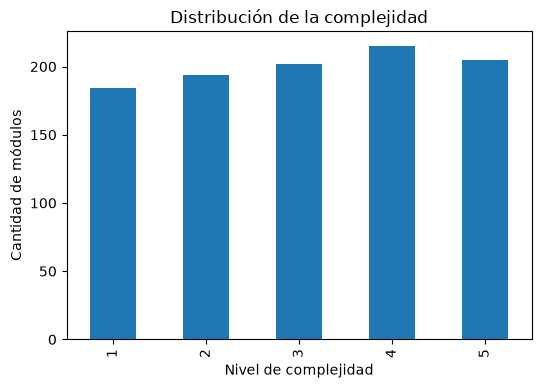

In [10]:
data["complejidad"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(6,4),
    title="Distribución de la complejidad"
)

plt.xlabel("Nivel de complejidad")
plt.ylabel("Cantidad de módulos")
plt.show()

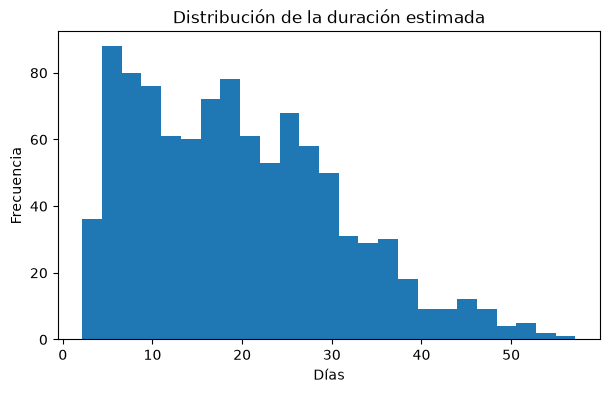

In [11]:
# Visualización de la duración estimada
plt.figure(figsize=(7,4))

plt.hist(data["duracion_estimada_dias"], bins=25)

plt.title("Distribución de la duración estimada")
plt.xlabel("Días")
plt.ylabel("Frecuencia")

plt.show()

In [12]:
# Matriz de correlación
correlacion = data.drop(columns=["modulo"]).corr()

correlacion

,interfaces_usuario,funcionalidades_backend,complejidad,horas_disponibles_dia,duracion_estimada_dias
interfaces_usuario,1.000000,0.869554,0.898561,-0.007387,0.820935
funcionalidades_backend,0.869554,1.000000,0.964842,-0.011190,0.847930
complejidad,0.898561,0.964842,1.000000,-0.011156,0.855725
horas_disponibles_dia,-0.007387,-0.011190,-0.011156,1.000000,-0.435097
duracion_estimada_dias,0.820935,0.847930,0.855725,-0.435097,1.000000


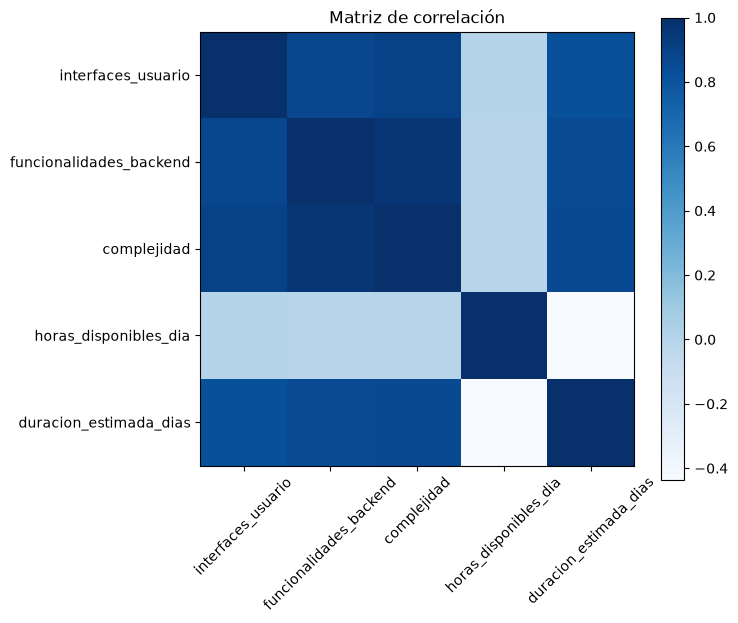

In [13]:
plt.figure(figsize=(7,6))

plt.imshow(correlacion, cmap="Blues")

plt.colorbar()

plt.xticks(range(len(correlacion.columns)), correlacion.columns, rotation=45)
plt.yticks(range(len(correlacion.columns)), correlacion.columns)

plt.title("Matriz de correlación")

plt.show()

#División de datos

### Variables predictoras


*   interfaces_usuario
*   funcionalidades_backend
*   complejidad
*   horas_disponibles_dia

### Variable objetivo

*   duracion_estimada_dias







In [14]:
# Variables predictoras (X)
X = data[[
    "interfaces_usuario",
    "funcionalidades_backend",
    "complejidad",
    "horas_disponibles_dia"
]]

# Variable objetivo (y)
y = data["duracion_estimada_dias"]

# División entrenamiento y prueba (Train/test)

Usaremos una división **80% entrenamiento y 20% prueba**.






In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (800, 4)
Datos de prueba: (200, 4)


# Entrenamiento del modelo

Se utilizó un modelo de regresión lineal para representar la relación entre el tiempo de desarrollo y la cantidad y complejidad de las funcionalidades.

In [16]:
with mlflow.start_run(run_name="LinearRegression_v1") as run:

    # Crear y entrenar el modelo
    modelo = LinearRegression()
    modelo.fit(X_train, y_train)

    # Realizar predicciones
    y_pred = modelo.predict(X_test)

    # Calcular métricas
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    # Registrar parámetros en MLflow
    mlflow.log_params({
        "algoritmo": "LinearRegression",
        "test_size": TEST_SIZE,
        "random_state": RANDOM_STATE,
        "numero_registros": len(data),
        "registros_entrenamiento": len(X_train),
        "registros_prueba": len(X_test),
        "numero_variables_entrada": X.shape[1]
    })

    # Registrar métricas en MLflow
    mlflow.log_metrics({
        "mae": float(mae),
        "rmse": float(rmse),
        "r2": float(r2)
    })

    # Registrar etiquetas descriptivas
    mlflow.set_tags({
        "proyecto": "Estimador de tiempo de desarrollo de módulos",
        "actividad": "Monitorización y observabilidad",
        "tipo_modelo": "Regresión",
        "framework_api": "FastAPI",
        "entorno": "local"
    })

    # Guardar el modelo que utilizará FastAPI
    joblib.dump(modelo, "app/modelo.pkl")

    # Registrar el modelo en MLflow
    mlflow.sklearn.log_model(
        sk_model=modelo,
        name="modelo_regresion"
    )

    # Crear metadatos dinámicos
    metadata = {
        "nombre_proyecto": "Estimador de tiempo de desarrollo de módulos",
        "version_modelo": "1.1.0",
        "fecha_entrenamiento": datetime.now(timezone.utc).isoformat(),
        "modelo": "Regresión Lineal",
        "framework": "scikit-learn",
        "tipo_problema": "Regresión",
        "variable_objetivo": "duracion_estimada_dias",
        "variables_entrada": list(X.columns),
        "mlflow_run_id": run.info.run_id,
        "mlflow_experiment_id": run.info.experiment_id,
        "metricas": {
            "MAE": round(float(mae), 4),
            "RMSE": round(float(rmse), 4),
            "R2": round(float(r2), 4)
        },
        "descripcion": (
            "Modelo de machine learning para estimar la duración "
            "del desarrollo de módulos de software."
        )
    }

    with open(
        "app/metadata_modelo.json",
        "w",
        encoding="utf-8"
    ) as archivo:
        json.dump(metadata, archivo, indent=4, ensure_ascii=False)

    # Registrar artefactos
    mlflow.log_artifact(
        "datos/dataset_sintetico.csv",
        artifact_path="datos"
    )

    mlflow.log_artifact(
        "app/modelo.pkl",
        artifact_path="modelo_joblib"
    )

    mlflow.log_artifact(
        "app/metadata_modelo.json",
        artifact_path="metadata"
    )

    print("Modelo entrenado y registrado correctamente.")
    print(f"Run ID: {run.info.run_id}")
    print(f"MAE : {mae:.2f} días")
    print(f"RMSE: {rmse:.2f} días")
    print(f"R²  : {r2:.4f}")

Modelo entrenado y registrado correctamente.
Run ID: a7d679679d93442e9a8d49e501a06593
MAE : 2.39 días
RMSE: 3.15 días
R²  : 0.9323


# Evaluación del modelo

Utilizaremos las métricas adecuadas para un problema de regresión



*   MAE (Error Absoluto Medio, )
*   RMSE (Raíz del Error Cuadrático Medio)
*   R² (Coeficiente de determinación)



In [17]:
# Comparación valores reales y predichos
resultados = pd.DataFrame({
    "Real": y_test.values,
    "Predicción": np.round(y_pred, 2)
})

resultados.head(10)

,Real,Predicción
0,15.10,18.10
1,38.20,32.05
2,8.84,6.84
3,13.58,14.85
4,7.08,11.28
5,39.69,37.68
6,8.88,6.17
7,9.50,10.85
8,32.00,29.97
9,10.97,9.90


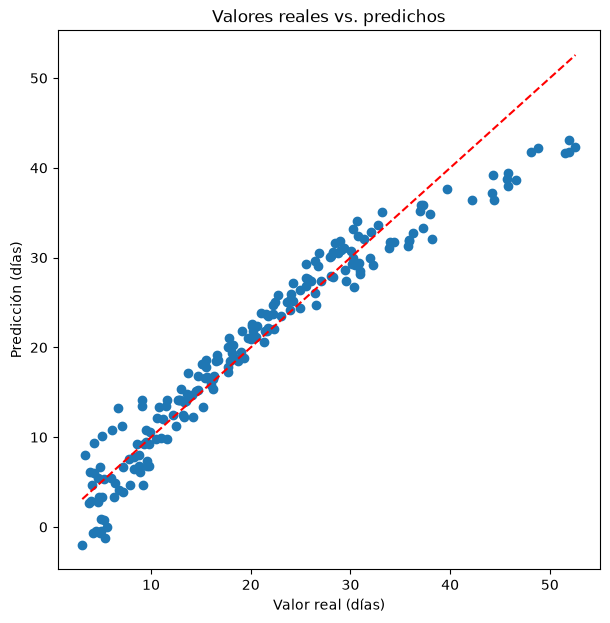

In [18]:
# Visualización de desempeño del modelo
plt.figure(figsize=(7,7))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Valor real (días)")
plt.ylabel("Predicción (días)")
plt.title("Valores reales vs. predichos")

plt.show()

In [19]:
print(f"""
Interpretación:

El modelo presentó un buen desempeño predictivo sobre el conjunto
de datos sintéticos generado, alcanzando un coeficiente de
determinación R² de {r2 * 100:.2f} %.

El error absoluto medio fue de {mae:.2f} días y el RMSE fue de
{rmse:.2f} días.

La ejecución quedó registrada en MLflow con el Run ID:

{run.info.run_id}
""")


Interpretación:

El modelo presentó un buen desempeño predictivo sobre el conjunto
de datos sintéticos generado, alcanzando un coeficiente de
determinación R² de 93.23 %.

El error absoluto medio fue de 2.39 días y el RMSE fue de
3.15 días.

La ejecución quedó registrada en MLflow con el Run ID:

a7d679679d93442e9a8d49e501a06593



In [20]:
# Verificar solamente las carpetas principales del proyecto
for ruta in ["app", "datos", "docs", "evidencias", "logs", "dashboard"]:
    print(f"\n{ruta}/")

    if os.path.exists(ruta):
        for elemento in os.listdir(ruta):
            print("   └──", elemento)


app/
   └── main.py
   └── metadata_modelo.json
   └── modelo.pkl
   └── __pycache__

datos/
   └── dataset_sintetico.csv

docs/
   └── Manual_Despliegue_Nube.md
   └── Validacion_Pruebas.md

evidencias/
   └── caso_error_422.png
   └── caso_maximo.png
   └── caso_minimo.png
   └── docker_build.png
   └── docker_run.png
   └── get_inicio.png
   └── predict_normal.png

logs/

dashboard/
